In [9]:
!pip install keras-nlp


In [10]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import keras_nlp
import pandas as pd
from pathlib import Path

AUTOTUNE = tf.data.AUTOTUNE


In [11]:
sequence_length = 128
text_preprocessor = keras_nlp.models.DistilBertPreprocessor.from_preset(
    "distil_bert_base_en_uncased",
    sequence_length=sequence_length
)

text_encoder = keras_nlp.models.DistilBertBackbone.from_preset(
    "distil_bert_base_en_uncased"
)
#freezing
text_encoder.trainable = False


100%|██████████| 462/462 [00:00<00:00, 656kB/s]


100%|██████████| 794/794 [00:00<00:00, 1.65MB/s]


100%|██████████| 226k/226k [00:00<00:00, 973kB/s]


100%|██████████| 253M/253M [00:05<00:00, 44.3MB/s]


In [12]:
def make_clip_dataset_distilbert(
    captions_csv_path,
    dataset_dir,
    batch_size=16,
    shuffle=True,
    drop_remainder=True,
    cache=True,
    seed=42,
):
    df = pd.read_csv(captions_csv_path)
    image_paths = df["image_path"].astype(str).tolist()
    captions    = df["caption"].fillna("").astype(str).tolist()

    root = Path(dataset_dir)
    full_paths = [str(Path(dataset_dir) / p) for p in image_paths]

    ds = tf.data.Dataset.from_tensor_slices((full_paths, captions))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(full_paths), seed=seed,
                        reshuffle_each_iteration=True)

    def load_sample(img_path, caption):
        #preprocessing des images
        img = tf.io.read_file(img_path)
        img = tf.image.decode_jpeg(img, channels=3)
        img = tf.image.resize(img, [224, 224])
        img = tf.image.convert_image_dtype(img, tf.float32)

        #preprocessing texte
        tokens = text_preprocessor(caption)
        token_ids = tf.cast(tokens["token_ids"], tf.int32)
        padding_mask = tf.cast(tokens["padding_mask"], tf.int32)

        return {
            "image_input": img,
            "input_ids": token_ids,
            "attention_mask": padding_mask
        }

    ds = ds.map(load_sample, num_parallel_calls=AUTOTUNE)
    if cache:
        ds = ds.cache()
    ds = ds.batch(batch_size, drop_remainder=drop_remainder).prefetch(AUTOTUNE)
    return ds


In [13]:
def build_image_encoder(embed_dim=256, nb_filters=32):
    inputs = layers.Input(shape=(224,224,3))
    x = layers.Conv2D(nb_filters, 3, activation="relu")(inputs)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Conv2D(nb_filters*2, 3, activation="relu")(x)
    x = layers.GlobalAveragePooling2D()(x)
    outputs = layers.Dense(embed_dim)(x)
    return keras.Model(inputs, outputs, name="image_encoder")


In [14]:
class ClipLossLayer(layers.Layer):
    def call(self, inputs):
        image_vec, text_vec = inputs
        image_vec = tf.math.l2_normalize(image_vec, axis=-1)
        text_vec = tf.math.l2_normalize(text_vec, axis=-1)
        logits = tf.matmul(image_vec, text_vec, transpose_b=True)
        labels = tf.range(tf.shape(logits)[0])
        loss_i = tf.nn.sparse_softmax_cross_entropy_with_logits(labels, logits)
        loss_t = tf.nn.sparse_softmax_cross_entropy_with_logits(labels, tf.transpose(logits))
        self.add_loss(tf.reduce_mean((loss_i + loss_t)/2))
        return logits

In [15]:
def build_text_projection_head(embed_dim=256, sequence_length=128):
    #tete entraînable qui projette les embeddings de DistilBERT

    input_ids = layers.Input(shape=(sequence_length,), dtype=tf.int32, name="input_ids")
    attention_mask = layers.Input(shape=(sequence_length,), dtype=tf.int32, name="attention_mask")

    #frozen encoder
    text_outputs = text_encoder({"token_ids": input_ids, "padding_mask": attention_mask})
    cls_embedding = text_outputs[:,0,:]

    #projection layer
    x = layers.Dense(embed_dim)(cls_embedding)
    x = layers.LayerNormalization()(x)

    return keras.Model(inputs=[input_ids, attention_mask], outputs=x, name="projection_head")

In [16]:
def build_clip_classifier_distilbert(embed_dim=256, nb_image_filters=32, sequence_length=128):
    image_inputs = layers.Input(shape=(224,224,3), name="image_input")
    input_ids = layers.Input(shape=(sequence_length,), dtype=tf.int32, name="input_ids")
    attention_mask = layers.Input(shape=(sequence_length,), dtype=tf.int32, name="attention_mask")

    text_head = build_text_projection_head(embed_dim, sequence_length)
    text_proj = text_head([input_ids, attention_mask])

    image_vector = build_image_encoder(embed_dim, nb_image_filters)(image_inputs)

    clip_logits = ClipLossLayer()([image_vector, text_proj])

    model = keras.Model(
        inputs=[image_inputs, input_ids, attention_mask],
        outputs=clip_logits,
        name="clip_training"
    )
    model.compile(optimizer=keras.optimizers.Adam(1e-4))
    return model

In [ ]:
'''
class ClipLossLayer(layers.Layer):
    def call(self, inputs):
        image_vec, text_vec = inputs
        image_vec = tf.math.l2_normalize(image_vec, axis=-1)
        text_vec = tf.math.l2_normalize(text_vec, axis=-1)
        logits = tf.matmul(image_vec, text_vec, transpose_b=True)
        labels = tf.range(tf.shape(logits)[0])
        loss_i = tf.nn.sparse_softmax_cross_entropy_with_logits(labels, logits)
        loss_t = tf.nn.sparse_softmax_cross_entropy_with_logits(labels, tf.transpose(logits))
        self.add_loss(tf.reduce_mean((loss_i + loss_t)/2))
        return logits

def build_clip_classifier_distilbert(embed_dim=256, nb_image_filters=32, sequence_length=128):
    #inputs
    image_inputs = layers.Input(shape=(224,224,3), name="image_input")
    input_ids = layers.Input(shape=(sequence_length,), dtype=tf.int32, name="input_ids")
    attention_mask = layers.Input(shape=(sequence_length,), dtype=tf.int32, name="attention_mask")

    # Text encoding
    text_outputs = text_encoder({"token_ids": input_ids, "padding_mask": attention_mask})

    #cls token
    text_vector = text_outputs[:,0,:]
    text_proj = layers.Dense(embed_dim)(text_vector)

    # Image encoding
    image_vector = build_image_encoder(embed_dim, nb_image_filters)(image_inputs)

    # clip loss
    clip_logits = ClipLossLayer()([image_vector, text_proj])

    # build
    model = keras.Model(
        inputs=[image_inputs, input_ids, attention_mask],
        outputs=clip_logits,
        name="clip_training"
    )
    model.compile(optimizer=keras.optimizers.Adam(1e-4))
    return model

'''


'\nclass ClipLossLayer(layers.Layer):\n    def call(self, inputs):\n        image_vec, text_vec = inputs\n        image_vec = tf.math.l2_normalize(image_vec, axis=-1)\n        text_vec = tf.math.l2_normalize(text_vec, axis=-1)\n        logits = tf.matmul(image_vec, text_vec, transpose_b=True)\n        labels = tf.range(tf.shape(logits)[0])\n        loss_i = tf.nn.sparse_softmax_cross_entropy_with_logits(labels, logits)\n        loss_t = tf.nn.sparse_softmax_cross_entropy_with_logits(labels, tf.transpose(logits))\n        self.add_loss(tf.reduce_mean((loss_i + loss_t)/2))\n        return logits\n\ndef build_clip_classifier_distilbert(embed_dim=256, nb_image_filters=32, sequence_length=128):\n    #inputs\n    image_inputs = layers.Input(shape=(224,224,3), name="image_input")\n    input_ids = layers.Input(shape=(sequence_length,), dtype=tf.int32, name="input_ids")\n    attention_mask = layers.Input(shape=(sequence_length,), dtype=tf.int32, name="attention_mask")\n\n    # Text encoding\n  

In [3]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [2]:
import sys
my_local_drive='/content/gdrive/My Drive/Colab Notebooks/ML_FDS'
sys.path.append(my_local_drive)

In [7]:
import pandas as pd
df = pd.read_csv(my_local_drive + "/flickr_subset2/captions.csv")
print(df["image_path"].head())


0    images/dog/dog_001.jpg
1    images/dog/dog_002.jpg
2    images/dog/dog_003.jpg
3    images/dog/dog_004.jpg
4    images/dog/dog_005.jpg
Name: image_path, dtype: object


In [17]:
train_ds = make_clip_dataset_distilbert(
    captions_csv_path=my_local_drive + "/flickr_subset2/train_data/captions.csv",
    dataset_dir=my_local_drive + "/flickr_subset2",
    batch_size=32,
    shuffle=True
)

val_ds = make_clip_dataset_distilbert(
    captions_csv_path=my_local_drive + "/flickr_subset2/val_data/captions.csv",
    dataset_dir=my_local_drive + "/flickr_subset2",
    batch_size=32,
    shuffle=False
)


clip_model = build_clip_classifier_distilbert(embed_dim=256)

clip_model.summary()

print("\n=== Parameters ===")
trainable_count = sum([tf.size(w).numpy() for w in clip_model.trainable_weights])
non_trainable_count = sum([tf.size(w).numpy() for w in clip_model.non_trainable_weights])
print(f"Trainable parameters: {trainable_count:,}")
print(f"Non-trainable parameters (frozen DistilBERT): {non_trainable_count:,}")
print(f"Total parameters: {trainable_count + non_trainable_count:,}")

# Train the model and capture history
history = clip_model.fit(train_ds, epochs=10, validation_data=val_ds)
clip_model.save("/content/clip_model_distilbert.h5")

print("\n Model saved successfully!")

Model: "clip_training"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_ids           │ (None, 128)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_mask      │ (None, 128)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ image_encoder       │ (None, 256)       │     36,032 │ image_input[0][0] │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ projection_head     │ (None, 256)       │ 66,560,256 │ input_ids[0][0],  │
│ (Functional)        │                   │            │ attention_mask[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ clip_loss_layer     │ (None, None)      │          0 │ image_encoder[0]… │
│ (ClipLossLayer)     │                   │            │ projection_head[… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 66,596,288 (254.04 MB)

 Trainable params: 233,408 (911.75 KB)

 Non-trainable params: 66,362,880 (253.15 MB)


=== Parameters ===
Trainable parameters: 233,408
Non-trainable parameters (frozen DistilBERT): 66,362,880
Total parameters: 66,596,288
Epoch 1/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 275s 17s/step - loss: 3.4657 - val_loss: 3.4660
Epoch 2/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 241s 16s/step - loss: 3.4643 - val_loss: 3.4656
Epoch 3/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 248s 17s/step - loss: 3.4624 - val_loss: 3.4644
Epoch 4/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 242s 16s/step - loss: 3.4592 - val_loss: 3.4611
Epoch 5/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 241s 16s/step - loss: 3.4508 - val_loss: 3.4545
Epoch 6/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 242s 16s/step - loss: 3.4321 - val_loss: 3.4403
Epoch 7/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 241s 16s/step - loss: 3.4152 - val_loss: 3.4363
Epoch 8/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 263s 16s/step - loss: 3.3922 - val_loss: 3.4195
Epoch 9/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 241s 16s/step - loss: 3.3837 - val_loss: 3.4243
Epoch 10/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 264s 16s/step - loss: 3.3700 - val_loss: 3.4063



 Model saved successfully!


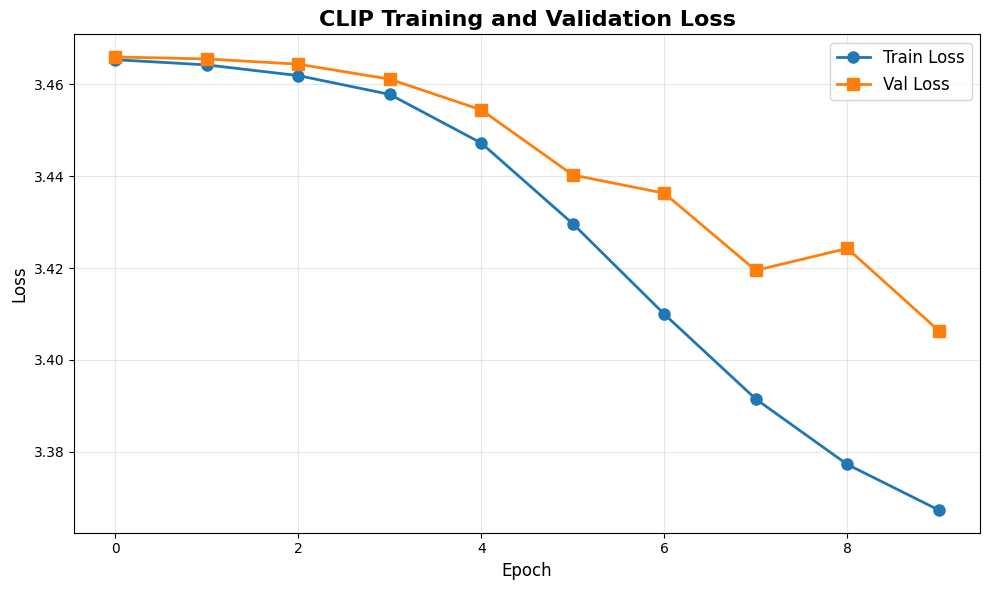


Final training loss: 3.3673
Final validation loss: 3.4063
Initial training loss: 3.4654
Train loss reduction: 0.0981


In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], marker='o', linewidth=2, markersize=8, label='Train Loss')
plt.plot(history.history['val_loss'], marker='s', linewidth=2, markersize=8, label='Val Loss')
plt.title('CLIP Training and Validation Loss', fontsize=16, fontweight='bold')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nFinal training loss: {history.history['loss'][-1]:.4f}")
print(f"Final validation loss: {history.history['val_loss'][-1]:.4f}")
print(f"Initial training loss: {history.history['loss'][0]:.4f}")
print(f"Train loss reduction: {history.history['loss'][0] - history.history['loss'][-1]:.4f}")

In [ ]:
''' train_ds = make_clip_dataset_distilbert(
    captions_csv_path=my_local_drive + "/flickr_subset2/captions.csv",
    dataset_dir=my_local_drive + "/flickr_subset2",
    batch_size=32
)


clip_model = build_clip_classifier_distilbert(embed_dim=256)
clip_model.fit(train_ds, epochs=10)
clip_model.save("/content/clip_model_distilbert.h5")
'''

' train_ds = make_clip_dataset_distilbert(\n    captions_csv_path=my_local_drive + "/flickr_subset2/captions.csv",\n    dataset_dir=my_local_drive + "/flickr_subset2",\n    batch_size=32\n)\n\n\nclip_model = build_clip_classifier_distilbert(embed_dim=256)\nclip_model.fit(train_ds, epochs=10)\nclip_model.save("/content/clip_model_distilbert.h5")\n'